# Boxplots

In [1]:
import os
os.environ["R_HOME"] = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/R"

qiime_env = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1"
os.environ["PATH"] = f"{qiime_env}/bin:/usr/local/bin:/usr/bin:/bin"
os.environ["CONDA_PREFIX"] = qiime_env


In [2]:
import ancombc2_heatmaps
print(ancombc2_heatmaps.__file__)

/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/python3.10/site-packages/ancombc2_heatmaps/__init__.py


In [3]:
from ancombc2_heatmaps import (
    PlotWorkflow,
    HeatmapConfig,
    MetadataConfig,
    ComparisonConfig,
    PathConfig,
    SubsetSpec,
    TrajectoryConfig,
    TrajectoryMetadataConfig,
    TrajectoryPathConfig,
    TrajectoryPlotConfig,
)

print("Imports ok")

Imports ok


In [4]:
META_FP = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/metadata_microbian2_26.02.2026.txt"

TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups"

ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups/ancombc2_treatment"

OUTDIR = "/tmp/ancombc2_notebook_test"

print("Paths ok")

Paths ok


In [5]:
TIMEPOINTS = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14"
]

TIMEPOINT_MAP = {
    "baseline_1": "baseline1",
    "baseline_2": "baseline2",
    "baseline_3": "baseline3",
    "day_1_post": "day1",
    "day_3_post": "day3",
    "day_7_post": "day7",
    "day_14_post": "day14",
    "baseline1": "baseline1",
    "baseline2": "baseline2",
    "baseline3": "baseline3",
    "day1": "day1",
    "day3": "day3",
    "day7": "day7",
    "day14": "day14",
}

TIMEPOINT_NUMERIC_MAP = {
    "baseline_1": -7,
    "baseline_2": -4,
    "baseline_3": -1,
    "day_1_post": 1,
    "day_3_post": 3,
    "day_7_post": 7,
    "day_14_post": 14,
    "baseline1": -7,
    "baseline2": -4,
    "baseline3": -1,
    "day1": 1,
    "day3": 3,
    "day7": 7,
    "day14": 14,
}

TP_LABEL_MAP = {
    0: "baseline",
    -7: "baseline1",
    -4: "baseline2",
    -1: "baseline3",
    1: "day1",
    3: "day3",
    7: "day7",
    14: "day14",
}

print("Timepoints ok")

Timepoints ok


In [6]:
heatmap_config = HeatmapConfig(
    metadata=MetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        comparison_col="description_of_treatment",
        timepoints=TIMEPOINTS,
        timepoint_map=TIMEPOINT_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["male", "female"],
        },
    ),
    comparison=ComparisonConfig(
        variable_name="description_of_treatment",
        positive_class="irradiated",
        negative_class="sham",
    ),
    paths=PathConfig(
        base_table_dir=TABLE_BASE,
        base_ancom_dir=ANCOM_BASE,
        metadata_path=META_FP,
        output_dir=OUTDIR,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_treat_ANCOMB_exported",
    ),
    cell_text_mode="relative_abundance",
    split_after_timepoint="baseline3",
    min_sig_cells_per_taxon=1,
)

print("Heatmap config ok")

Heatmap config ok


In [7]:
traj_config = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="description_of_treatment",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_treat_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=True,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={
            "sham": "",
            "irradiated": (4, 2),
        },
        figsize=(12, 8),
    ),
)

print("Trajectory config ok")

Trajectory config ok


In [8]:
workflow = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config,
)

print("Workflow ok")

subset = SubsetSpec(
    label="WT_genus_ANCOM",
    title="WT | sham vs irradiated",
    filters={
        "mice_model": "WT",
    },
)

print("Subset ok")

Workflow ok
Subset ok


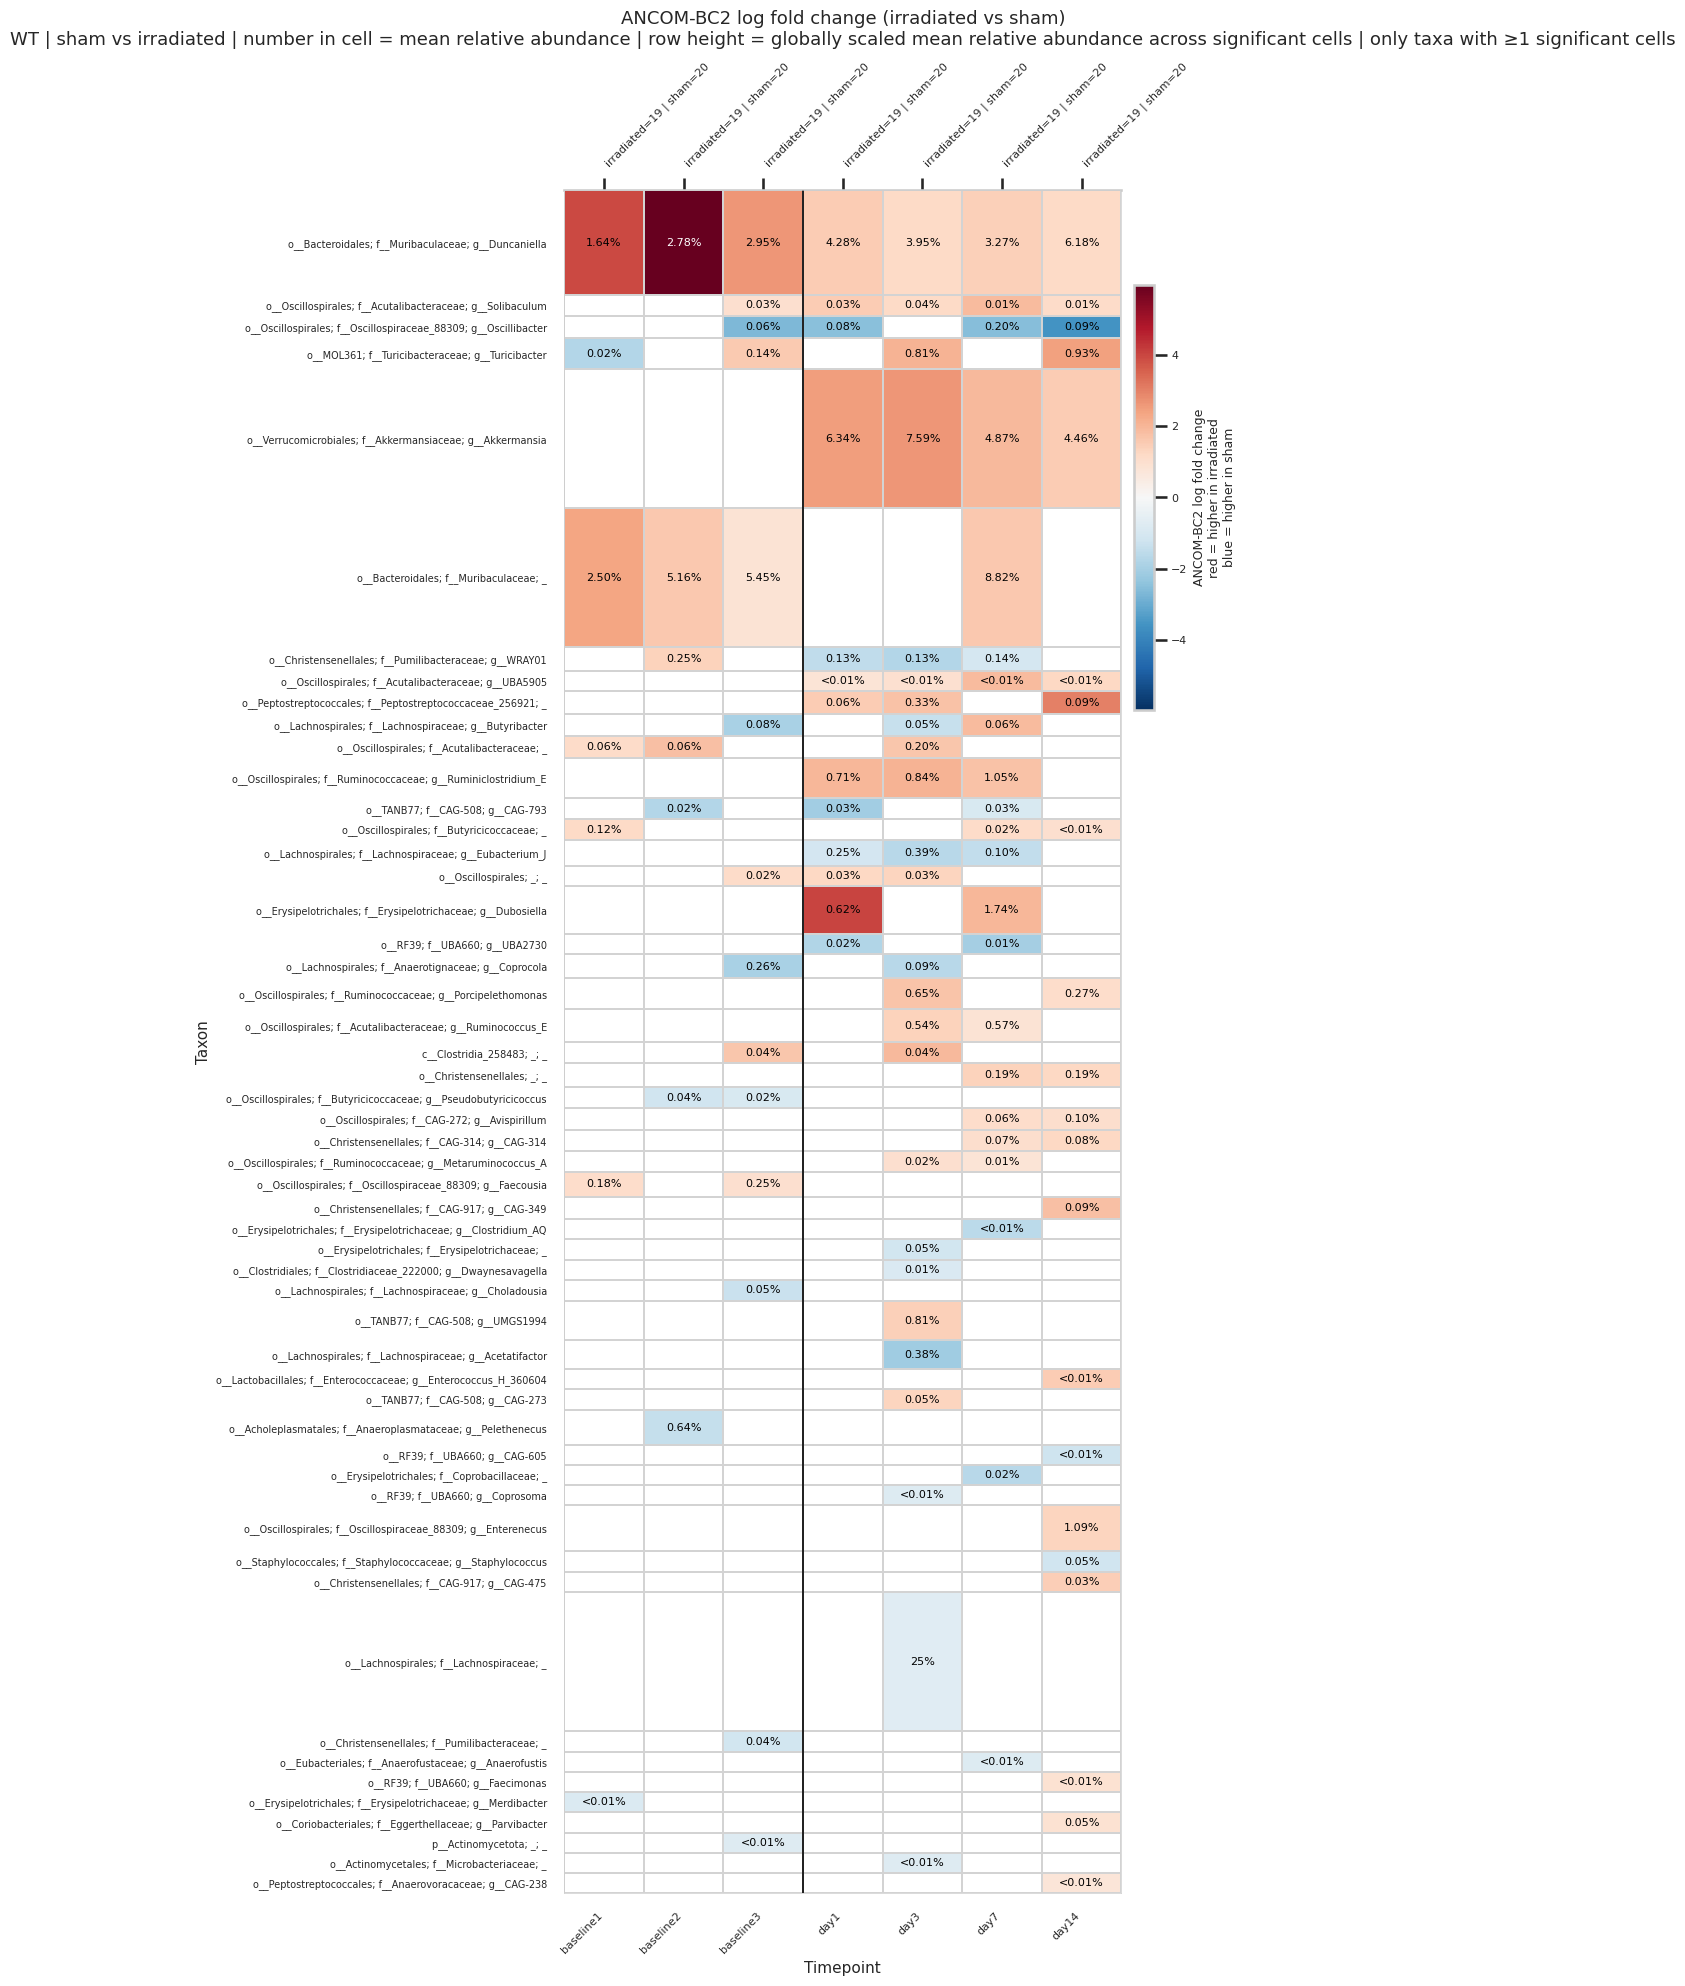

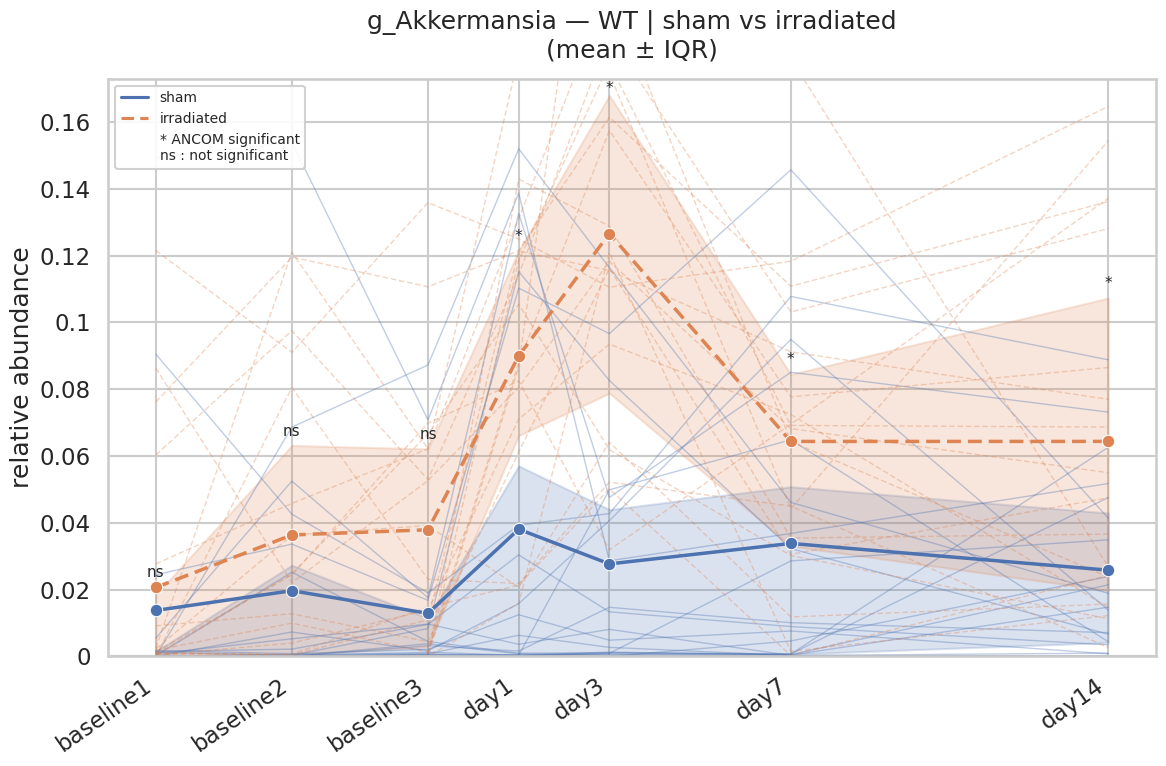

In [9]:
workflow.plot_heatmap_and_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
    heatmap_kwargs={
        "show": True,
        "save_png": False,
        "save_pdf": False,
    },
)

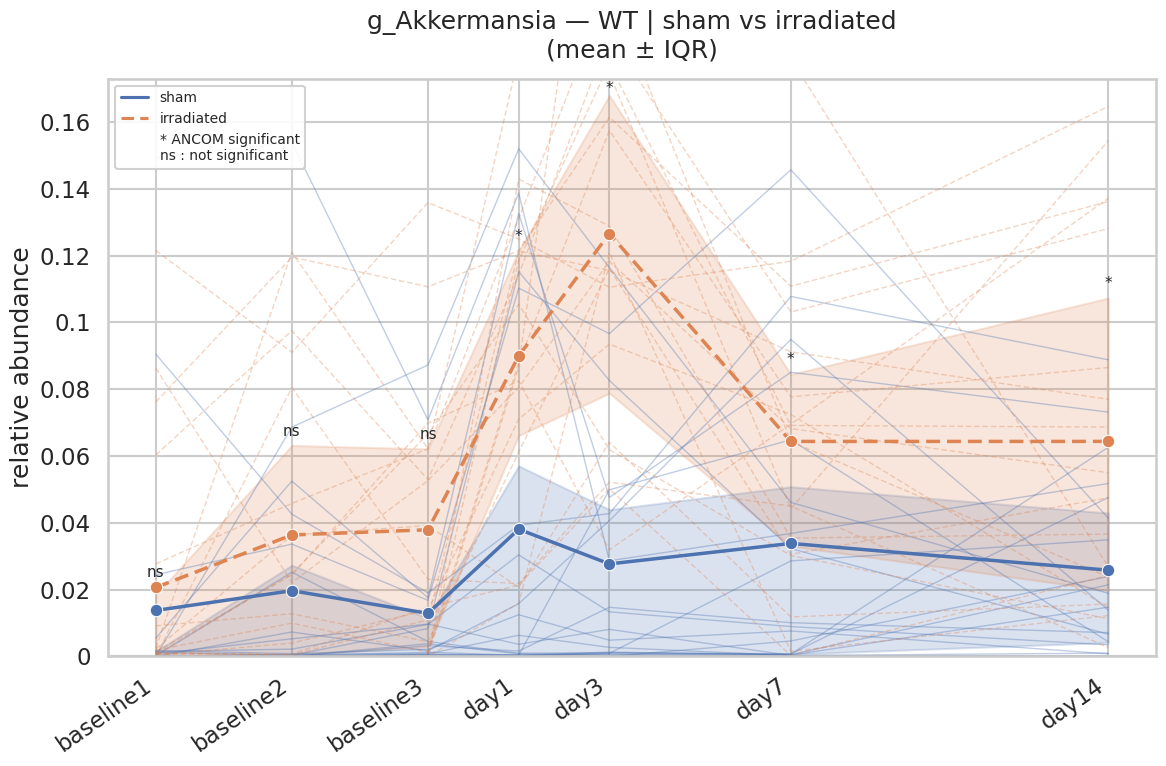

In [11]:
workflow.plot_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
)

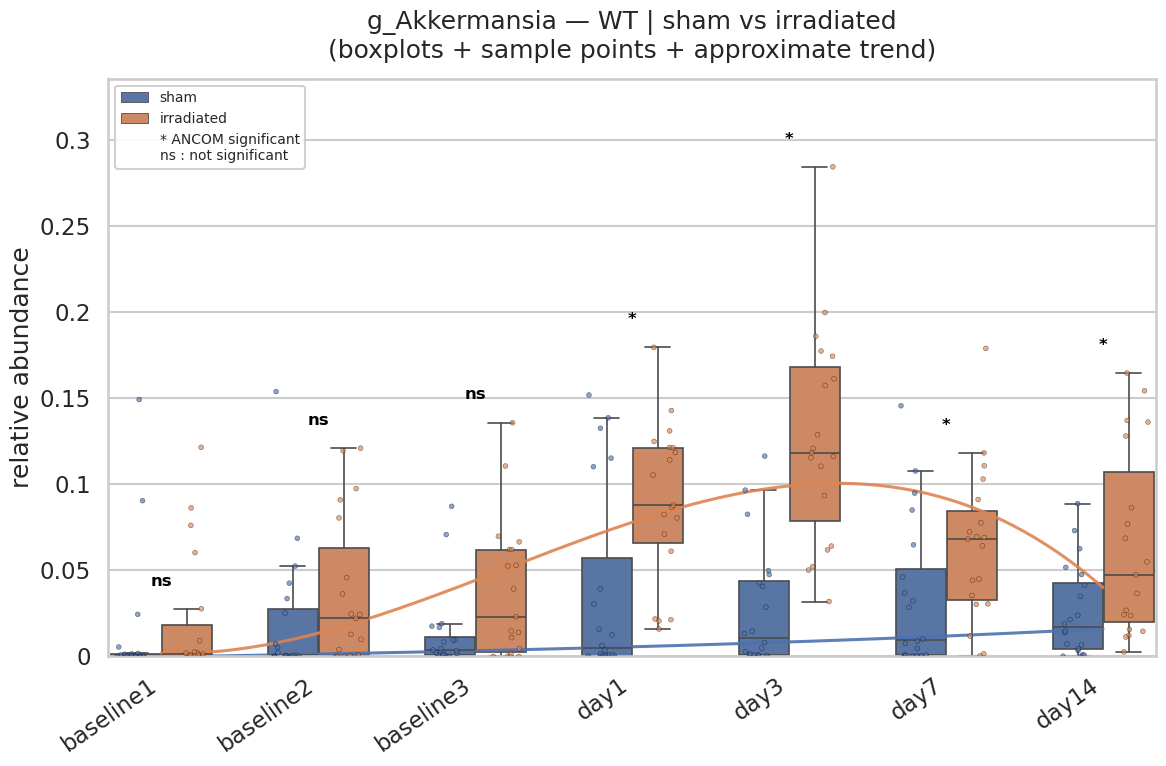

In [12]:
workflow.plot_boxplot_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
    show_trend=True,
    trend_order=3,
)

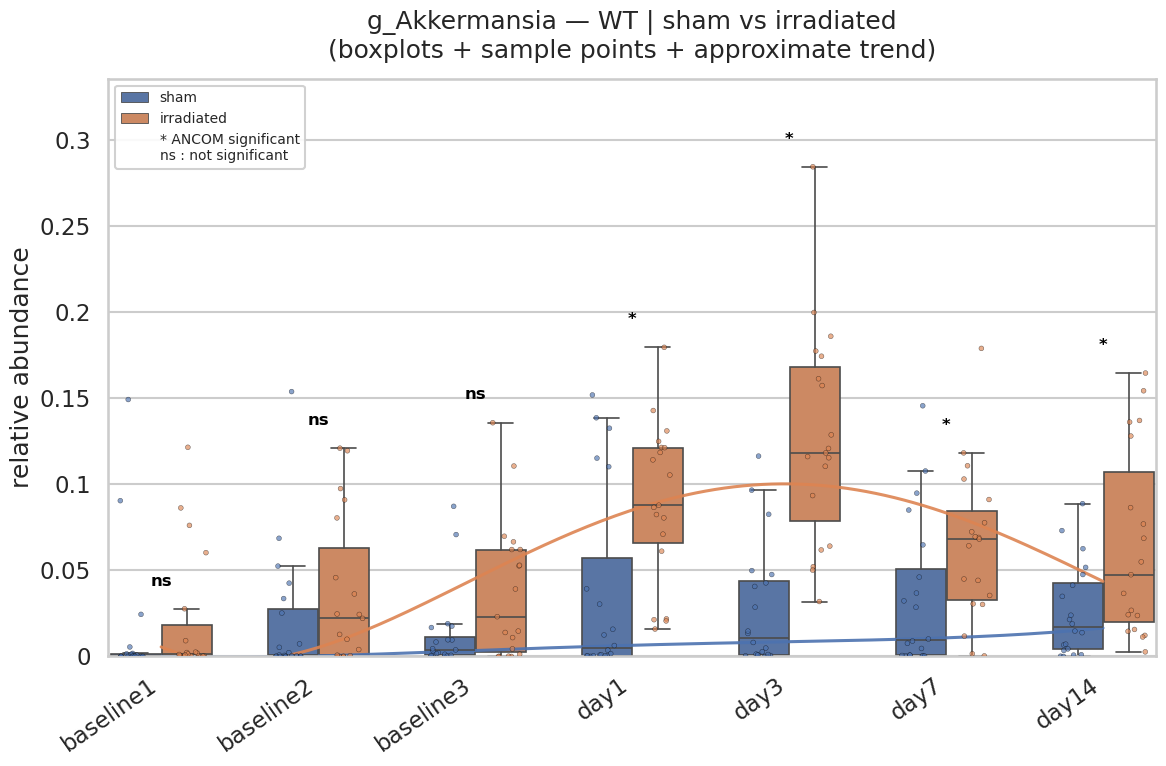

In [13]:
subset = SubsetSpec(
    label="WT_genus_ANCOM",
    title="WT | sham vs irradiated",
    filters={"mice_model": "WT"},
)

workflow.plot_boxplot_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
    show_trend=True,
    trend_order=4,
)

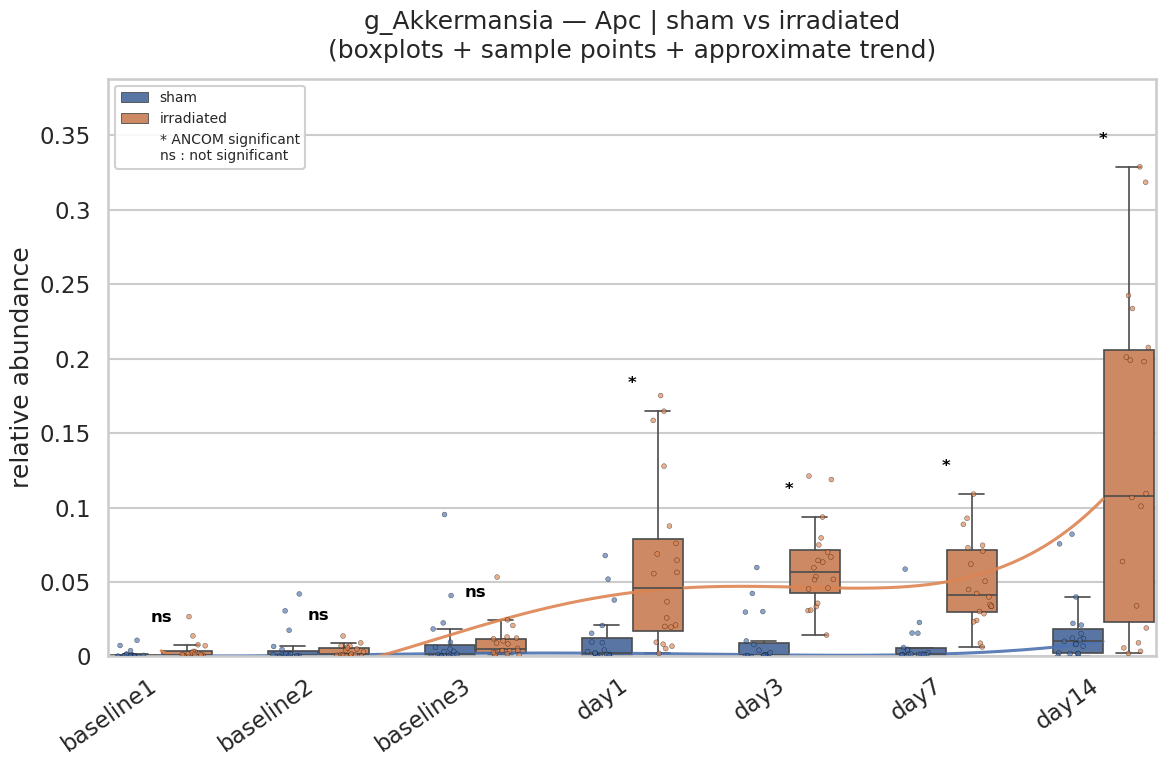

In [14]:
subset = SubsetSpec(
    label="Apc_genus_ANCOM",
    title="Apc | sham vs irradiated",
    filters={"mice_model": "Apc"},
)

workflow.plot_boxplot_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
    show_trend=True,
    trend_order=4,
)

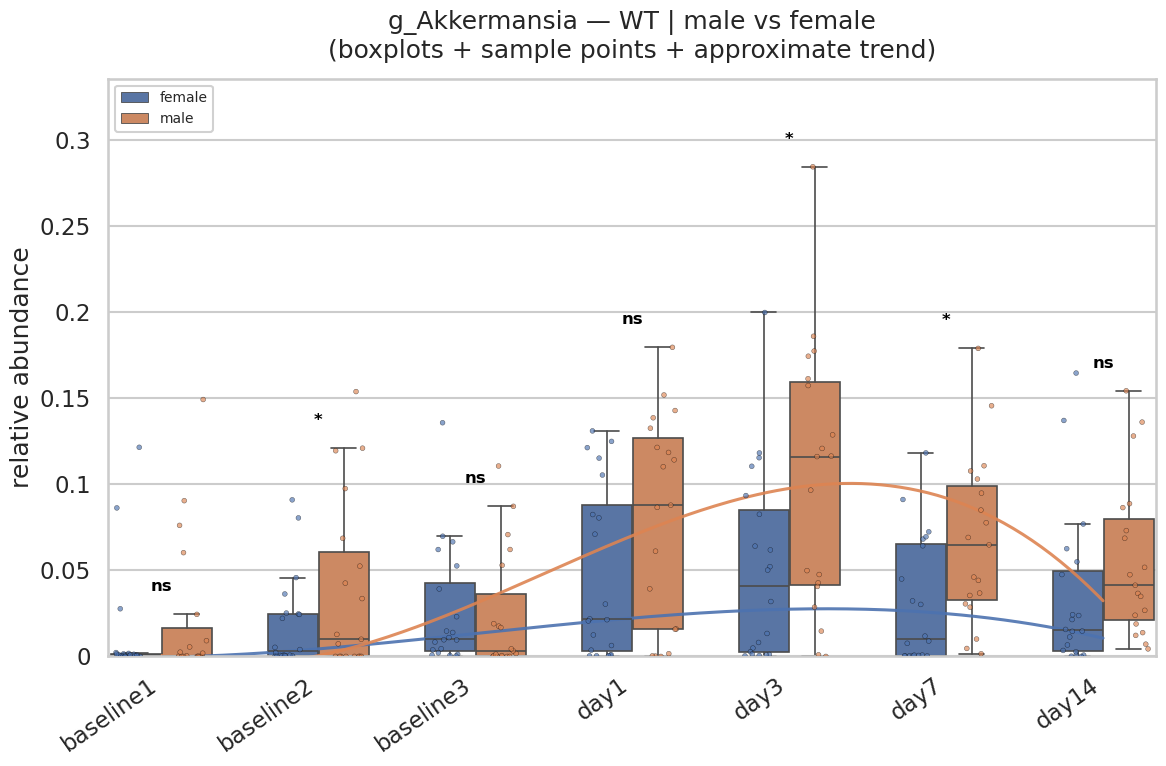

In [15]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex"

traj_config_sex = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_sex = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_sex,
)

subset_sex = SubsetSpec(
    label="WT_alltreat_genus_ANCOM",
    title="WT | male vs female",
    filters={"mice_model": "WT"},
)

workflow_sex.plot_boxplot_trajectory(
    subset=subset_sex,
    taxon_query="g_Akkermansia",
    comparison_levels=["female", "male"],
    show_trend=True,
    trend_order=3,
)

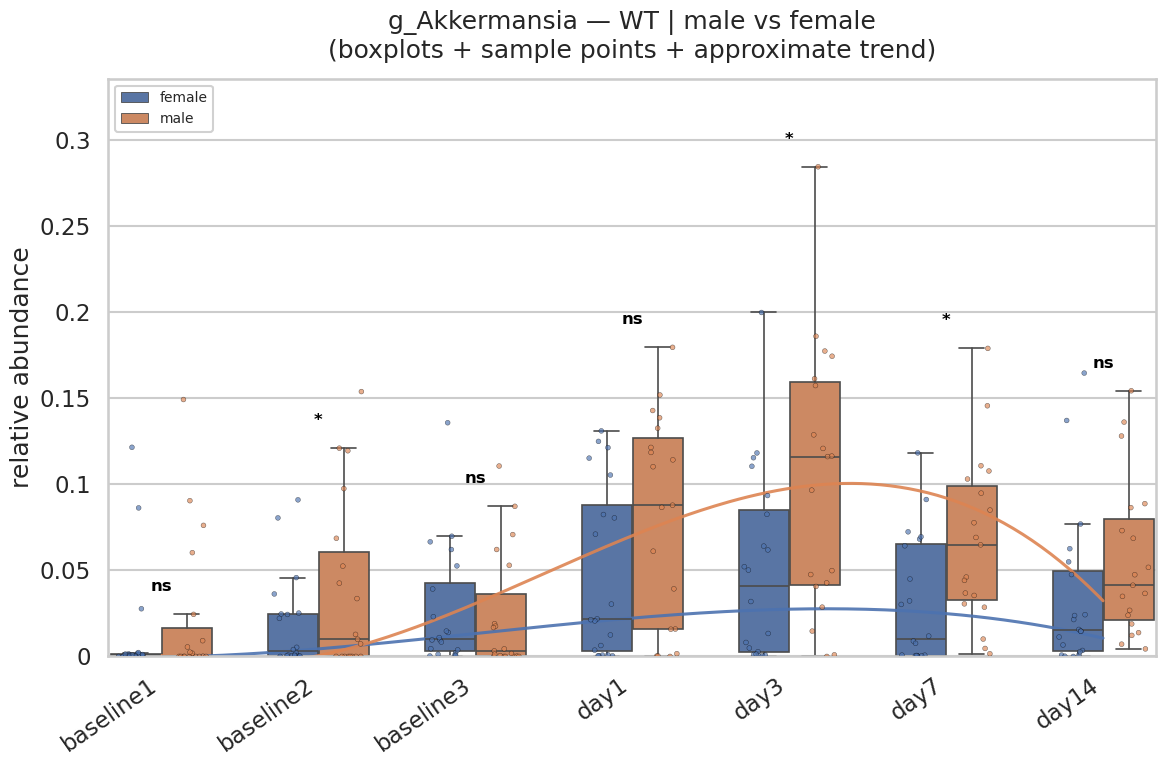

In [16]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex"

traj_config_sex = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_sex = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_sex,
)

subset_sex = SubsetSpec(
    label="WT_alltreat_genus_ANCOM",
    title="WT | male vs female",
    filters={"mice_model": "WT"},
)

workflow_sex.plot_boxplot_trajectory(
    subset=subset_sex,
    taxon_query="g_Akkermansia",
    comparison_levels=["female", "male"],
    show_trend=True,
    trend_order=3,
)

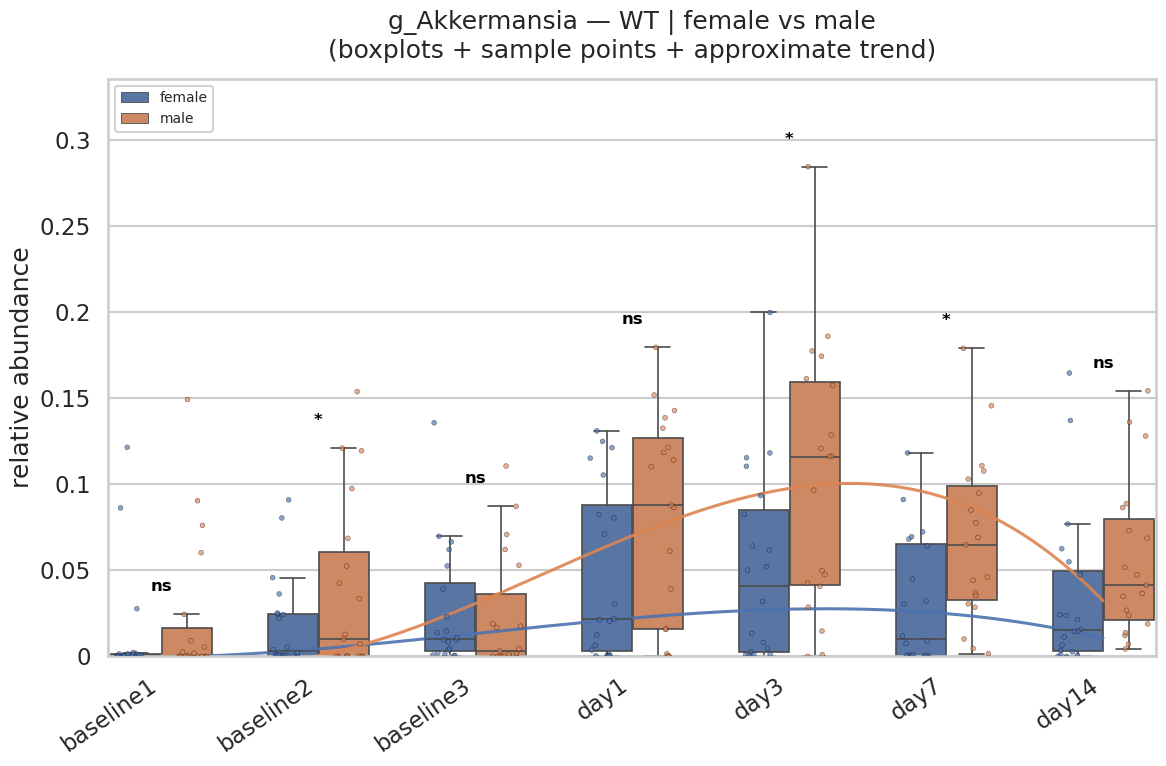

In [17]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex"

traj_config_sex_WT = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_sex_WT = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_sex_WT,
)

subset_sex_WT = SubsetSpec(
    label="WT_alltreat_genus_ANCOM",
    title="WT | female vs male",
    filters={"mice_model": "WT"},
)

workflow_sex_WT.plot_boxplot_trajectory(
    subset=subset_sex_WT,
    taxon_query="g_Akkermansia",
    comparison_levels=["female", "male"],
    show_trend=True,
    trend_order=3,
)

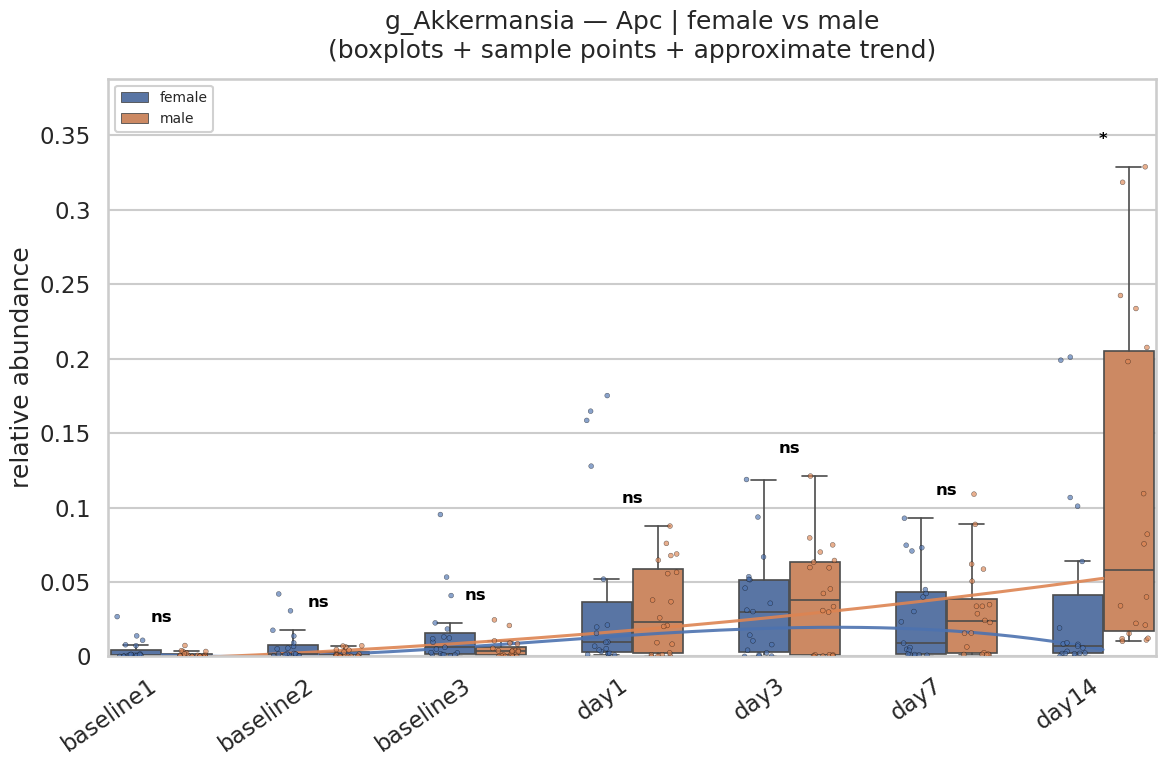

In [18]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex"

traj_config_sex_Apc = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_sex_Apc = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_sex_Apc,
)

subset_sex_Apc = SubsetSpec(
    label="Apc_alltreat_genus_ANCOM",
    title="Apc | female vs male",
    filters={"mice_model": "Apc"},
)

workflow_sex_Apc.plot_boxplot_trajectory(
    subset=subset_sex_Apc,
    taxon_query="g_Akkermansia",
    comparison_levels=["female", "male"],
    show_trend=True,
    trend_order=3,
)

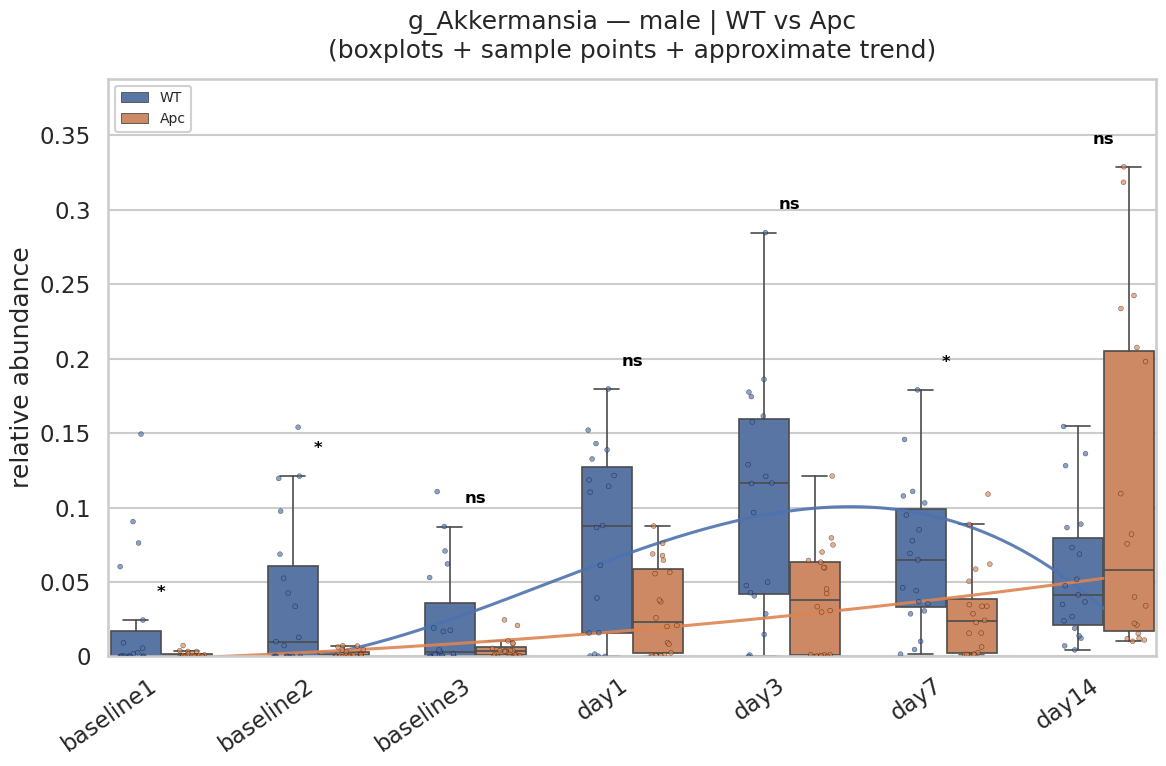

In [19]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype/ancombc2_genotype"

traj_config_genotype_male = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="mice_model",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["male"],
            "mice_model": ["WT", "Apc"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_genotype_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_genotype_male = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_genotype_male,
)

subset_genotype_male = SubsetSpec(
    label="male_alltreat_genus_ANCOM",
    title="male | WT vs Apc",
    filters={"sex": "male"},
)

workflow_genotype_male.plot_boxplot_trajectory(
    subset=subset_genotype_male,
    taxon_query="g_Akkermansia",
    comparison_levels=["WT", "Apc"],
    show_trend=True,
    trend_order=3,
)

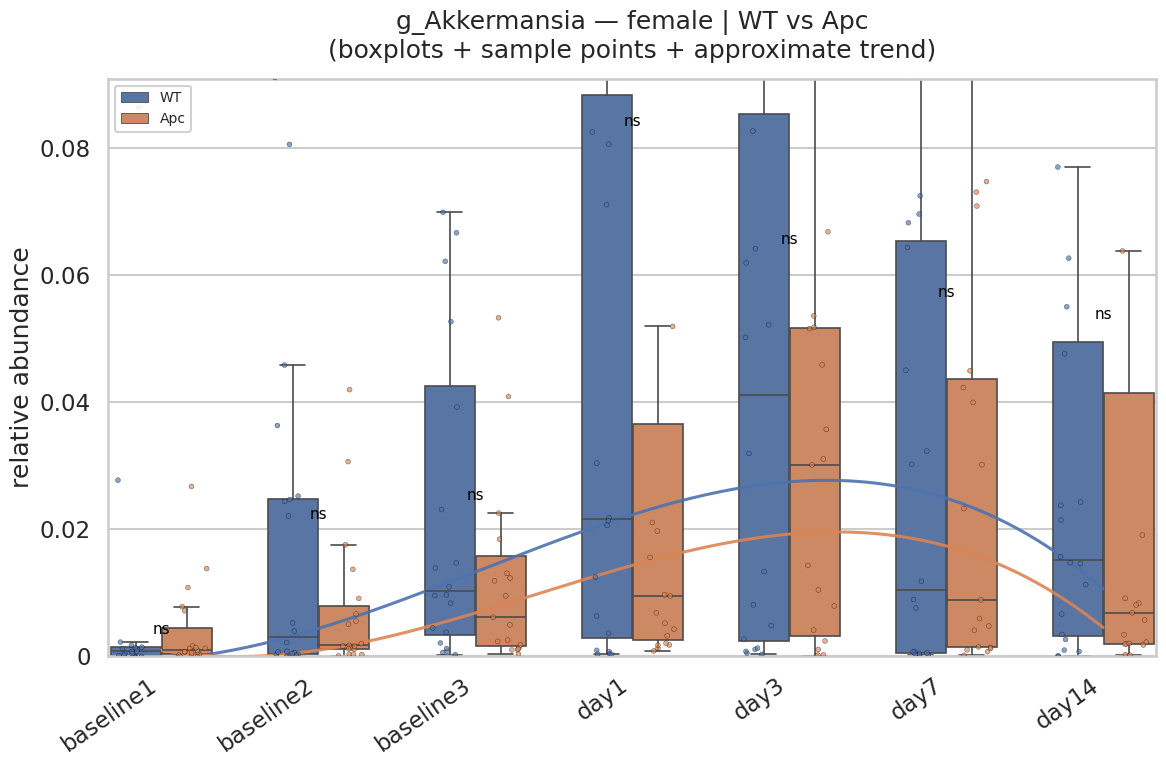

In [21]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype/ancombc2_genotype"

traj_config_genotype_female = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="mice_model",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female"],
            "mice_model": ["WT", "Apc"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_genotype_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_genotype_female = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_genotype_female,
)

subset_genotype_female = SubsetSpec(
    label="female_alltreat_genus_ANCOM",
    title="female | WT vs Apc",
    filters={"sex": "female"},
)

workflow_genotype_female.plot_boxplot_trajectory(
    subset=subset_genotype_female,
    taxon_query="g_Akkermansia",
    comparison_levels=["WT", "Apc"],
    show_trend=True,
    trend_order=3,
)

In [24]:
import os
import glob

# =========================================================
# PATHS
# =========================================================
TREAT_TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups"

SEX_TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex"

GENO_TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype"


# =========================================================
# SUBSET LABELS
# =========================================================
treatment_labels = [
    "all_genus_ANCOM",
    "WT_genus_ANCOM",
    "Apc_genus_ANCOM",
    "male_genus_ANCOM",
    "female_genus_ANCOM",
    "WT_male_genus_ANCOM",
    "WT_female_genus_ANCOM",
    "Apc_male_genus_ANCOM",
    "Apc_female_genus_ANCOM",
]

sex_labels = [
    "all_genus_ANCOM",
    "WT_alltreat_genus_ANCOM",
    "Apc_alltreat_genus_ANCOM",
    "sham_allgeno_genus_ANCOM",
    "irradiated_allgeno_genus_ANCOM",
    "WT_sham_genus_ANCOM",
    "WT_irradiated_genus_ANCOM",
    "Apc_sham_genus_ANCOM",
    "Apc_irradiated_genus_ANCOM",
]

genotype_labels = [
    "all_genus_ANCOM",
    "male_alltreat_genus_ANCOM",
    "female_alltreat_genus_ANCOM",
    "sham_allsex_genus_ANCOM",
    "irradiated_allsex_genus_ANCOM",
    "male_sham_genus_ANCOM",
    "male_irradiated_genus_ANCOM",
    "female_sham_genus_ANCOM",
    "female_irradiated_genus_ANCOM",
]


# =========================================================
# HELPER
# =========================================================
def print_matches(base, labels, title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    for label in labels:
        pattern = os.path.join(
            base,
            "*",
            f"table_*_{label}.qza"
        )

        matches = sorted(glob.glob(pattern))

        print(f"\n[{label}]")

        if len(matches) == 0:
            print("  NO FILES FOUND")
            continue

        for fp in matches:
            print(" ", os.path.basename(fp))


# =========================================================
# RUN
# =========================================================
print_matches(
    TREAT_TABLE_BASE,
    treatment_labels,
    "DESCRIPTION_OF_TREATMENT"
)

print_matches(
    SEX_TABLE_BASE,
    sex_labels,
    "SEX"
)

print_matches(
    GENO_TABLE_BASE,
    genotype_labels,
    "MICE_MODEL"
)


DESCRIPTION_OF_TREATMENT

[all_genus_ANCOM]
  NO FILES FOUND

[WT_genus_ANCOM]
  table_baseline1_WT_genus_ANCOM.qza
  table_baseline2_WT_genus_ANCOM.qza
  table_baseline3_WT_genus_ANCOM.qza
  table_day1_WT_genus_ANCOM.qza
  table_day14_WT_genus_ANCOM.qza
  table_day3_WT_genus_ANCOM.qza
  table_day7_WT_genus_ANCOM.qza

[Apc_genus_ANCOM]
  table_baseline1_Apc_genus_ANCOM.qza
  table_baseline2_Apc_genus_ANCOM.qza
  table_baseline3_Apc_genus_ANCOM.qza
  table_day1_Apc_genus_ANCOM.qza
  table_day14_Apc_genus_ANCOM.qza
  table_day3_Apc_genus_ANCOM.qza
  table_day7_Apc_genus_ANCOM.qza

[male_genus_ANCOM]
  table_baseline1_male_genus_ANCOM.qza
  table_baseline2_male_genus_ANCOM.qza
  table_baseline3_male_genus_ANCOM.qza
  table_day1_male_genus_ANCOM.qza
  table_day14_male_genus_ANCOM.qza
  table_day3_male_genus_ANCOM.qza
  table_day7_male_genus_ANCOM.qza

[female_genus_ANCOM]
  table_baseline1_female_genus_ANCOM.qza
  table_baseline2_female_genus_ANCOM.qza
  table_baseline3_female_genus_ANCOM

In [22]:
import os
import glob

BASE_DIR = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype_sex"
ANCOM_DIR = os.path.join(BASE_DIR, "ancombc2_treatment")

TIMEPOINTS = ["baseline1", "baseline2", "baseline3", "day1", "day3", "day7", "day14"]

print("BASE_DIR:")
print(BASE_DIR)

print("\nANCOM_DIR:")
print(ANCOM_DIR)

print("\nANCOM_DIR exists:", os.path.isdir(ANCOM_DIR))


# =========================================================
# TABLE FILES
# =========================================================
print("\n" + "=" * 100)
print("TABLE FILES")
print("=" * 100)

for tp in TIMEPOINTS:
    print(f"\n--- {tp} ---")

    pattern = os.path.join(BASE_DIR, tp, "*.qza")
    files = sorted(glob.glob(pattern))

    if not files:
        print("NO TABLE FILES FOUND")
    else:
        for fp in files:
            print(os.path.basename(fp))


# =========================================================
# ANCOM EXPORT DIRECTORIES
# =========================================================
print("\n" + "=" * 100)
print("ANCOM EXPORT DIRECTORIES")
print("=" * 100)

for tp in TIMEPOINTS:
    print(f"\n--- {tp} ---")

    pattern = os.path.join(ANCOM_DIR, tp, "*")
    dirs = sorted([p for p in glob.glob(pattern) if os.path.isdir(p)])

    if not dirs:
        print("NO ANCOM EXPORT DIRS FOUND")
    else:
        for d in dirs:
            print(os.path.basename(d))


# =========================================================
# CHECK CONTENT OF ANCOM EXPORT DIRECTORIES
# =========================================================
print("\n" + "=" * 100)
print("ANCOM EXPORT CONTENT CHECK")
print("=" * 100)

for tp in TIMEPOINTS:
    pattern = os.path.join(ANCOM_DIR, tp, "*")
    dirs = sorted([p for p in glob.glob(pattern) if os.path.isdir(p)])

    for d in dirs:
        lfc_fp = os.path.join(d, "lfc.jsonl")
        q_fp = os.path.join(d, "q.jsonl")
        diff_fp = os.path.join(d, "diff.jsonl")

        print(f"\n{tp} | {os.path.basename(d)}")
        print("  lfc.jsonl :", os.path.exists(lfc_fp))
        print("  q.jsonl   :", os.path.exists(q_fp))
        print("  diff.jsonl:", os.path.exists(diff_fp))

BASE_DIR:
/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype_sex

ANCOM_DIR:
/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype_sex/ancombc2_treatment

ANCOM_DIR exists: True

TABLE FILES

--- baseline1 ---
table_baseline1_Apc_female_ANCOM.qza
table_baseline1_Apc_female_genus_ANCOM.qza
table_baseline1_Apc_male_ANCOM.qza
table_baseline1_Apc_male_genus_ANCOM.qza
table_baseline1_WT_female_ANCOM.qza
table_baseline1_WT_female_genus_ANCOM.qza
table_baseline1_WT_male_ANCOM.qza
table_baseline1_WT_male_genus_ANCOM.qza

--- baseline2 ---
table_baseline2_Apc_female_ANCOM.qza
table_baseline2_Apc_female_genus_ANCOM.qza
table_baseline2_Apc_male_ANCOM.qza
table_baseline2_Apc_male_genus_ANCOM.qza
table_baseline2_WT_female_ANCOM.qza
table_baseline2_WT_female_genus_ANCOM.qza
table_baseline2_WT_male_ANCOM.qza
table_baseline2_WT_male_genus_ANCOM.qza

--- baseline3 ---
table_baseline3_Apc_f

In [23]:
import os
import re
import matplotlib.pyplot as plt
from IPython.utils import io

# =========================================================
# OUTPUT
# =========================================================
OUTDIR = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_treatment_by_genotype_sex_v3"
os.makedirs(OUTDIR, exist_ok=True)

TAXON_QUERY = "g_Akkermansia"
TREND_ORDER = 3

TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype_sex"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype_sex/ancombc2_treatment"


def safe_name(x):
    x = str(x)
    x = re.sub(r"[^\w\-\.]+", "_", x)
    x = re.sub(r"_+", "_", x).strip("_")
    return x


def make_treatment_workflow_by_genotype_sex():
    traj_config = TrajectoryConfig(
        metadata=TrajectoryMetadataConfig(
            sample_col="sample_name",
            timepoint_col="time_point",
            mouse_col="host_subject_id",
            comparison_col="description_of_treatment",
            genotype_col="mice_model",
            treatment_col="description_of_treatment",
            timepoint_order=TIMEPOINTS,
            timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
            timepoint_label_map=TP_LABEL_MAP,
            allowed_values={
                "description_of_treatment": ["sham", "irradiated"],
                "sex": ["female", "male"],
                "mice_model": ["WT", "Apc"],
            },
        ),
        paths=TrajectoryPathConfig(
            metadata_path=META_FP,
            table_base=TABLE_BASE,
            ancom_base=ANCOM_BASE,
            table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
            ancom_template="{timepoint}/table_{timepoint}_{subset_label}_treat_ANCOMB_exported",
        ),
        plot=TrajectoryPlotConfig(
            estimator="mean",
            error_style="iqr",
            show_individual_lines=False,
            merge_baselines=False,
            y_lim="auto_fix",
            show_significance=True,
            line_styles={},
            figsize=(12, 8),
        ),
    )

    return PlotWorkflow(
        heatmap_config=heatmap_config,
        trajectory_config=traj_config,
    )


workflow_treat_gs = make_treatment_workflow_by_genotype_sex()


subsets = [
    SubsetSpec(
        label="WT_female_genus_ANCOM",
        title="WT female | sham vs irradiated",
        filters={"mice_model": "WT", "sex": "female"},
    ),
    SubsetSpec(
        label="WT_male_genus_ANCOM",
        title="WT male | sham vs irradiated",
        filters={"mice_model": "WT", "sex": "male"},
    ),
    SubsetSpec(
        label="Apc_female_genus_ANCOM",
        title="Apc female | sham vs irradiated",
        filters={"mice_model": "Apc", "sex": "female"},
    ),
    SubsetSpec(
        label="Apc_male_genus_ANCOM",
        title="Apc male | sham vs irradiated",
        filters={"mice_model": "Apc", "sex": "male"},
    ),
]


plt.ioff()

for subset in subsets:
    out_fp = os.path.join(
        OUTDIR,
        f"{safe_name(TAXON_QUERY)}__{safe_name(subset.label)}__boxplot_trajectory.png"
    )

    plt.close("all")

    try:
        with io.capture_output() as captured:
            workflow_treat_gs.plot_boxplot_trajectory(
                subset=subset,
                taxon_query=TAXON_QUERY,
                comparison_levels=["sham", "irradiated"],
                show_trend=True,
                trend_order=TREND_ORDER,
            )

            fig = plt.gcf()
            fig.savefig(out_fp, dpi=300, bbox_inches="tight")
            plt.close(fig)

        print(f"[OK] saved: {out_fp}")

    except Exception as e:
        plt.close("all")
        print(f"[ERROR] {subset.label}: {e}")

plt.close("all")
plt.ion()

print(f"\nDone. Saved in:\n{OUTDIR}")

[OK] saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_treatment_by_genotype_sex_v3/g_Akkermansia__WT_female_genus_ANCOM__boxplot_trajectory.png
[OK] saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_treatment_by_genotype_sex_v3/g_Akkermansia__WT_male_genus_ANCOM__boxplot_trajectory.png
[OK] saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_treatment_by_genotype_sex_v3/g_Akkermansia__Apc_female_genus_ANCOM__boxplot_trajectory.png
[OK] saved: /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_treatment_by_genotype_sex_v3/g_Akkermansia__Apc_male_genus_ANCOM__boxplot_trajectory.png

Done. Saved in:
/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_treatment_by_genotype_sex_v3


In [25]:
import os
import glob

TIMEPOINTS = ["baseline1", "baseline2", "baseline3", "day1", "day3", "day7", "day14"]

CHECKS = {
    "treat_by_partial_groups": {
        "table_base": "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups",
        "ancom_base": "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups/ancombc2_treatment",
    },
    "treat_by_genotype_sex": {
        "table_base": "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype_sex",
        "ancom_base": "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype_sex/ancombc2_treatment",
    },
    "sex": {
        "table_base": "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex",
        "ancom_base": "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex",
    },
    "mice_model": {
        "table_base": "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype",
        "ancom_base": "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype/ancombc2_genotype",
    },
}


def print_existing_data(name, table_base, ancom_base):
    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)

    print("\nTABLE_BASE:")
    print(table_base)
    print("exists:", os.path.isdir(table_base))

    print("\nANCOM_BASE:")
    print(ancom_base)
    print("exists:", os.path.isdir(ancom_base))

    for tp in TIMEPOINTS:
        print("\n" + "-" * 100)
        print(tp)
        print("-" * 100)

        table_pattern = os.path.join(table_base, tp, "*.qza")
        ancom_pattern = os.path.join(ancom_base, tp, "*")

        table_files = sorted(glob.glob(table_pattern))
        ancom_dirs = sorted([p for p in glob.glob(ancom_pattern) if os.path.isdir(p)])

        print("\nTABLE FILES:")
        if table_files:
            for fp in table_files:
                print("  " + os.path.basename(fp))
        else:
            print("  NO TABLE FILES FOUND")

        print("\nANCOM EXPORT DIRS:")
        if ancom_dirs:
            for d in ancom_dirs:
                has_lfc = os.path.exists(os.path.join(d, "lfc.jsonl"))
                has_q = os.path.exists(os.path.join(d, "q.jsonl"))
                has_diff = os.path.exists(os.path.join(d, "diff.jsonl"))

                status = "OK" if has_lfc and has_q and has_diff else "INCOMPLETE"

                print(f"  {os.path.basename(d)}  [{status}]")
        else:
            print("  NO ANCOM DIRS FOUND")


for name, cfg in CHECKS.items():
    print_existing_data(
        name=name,
        table_base=cfg["table_base"],
        ancom_base=cfg["ancom_base"],
    )


treat_by_partial_groups

TABLE_BASE:
/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups
exists: True

ANCOM_BASE:
/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups/ancombc2_treatment
exists: True

----------------------------------------------------------------------------------------------------
baseline1
----------------------------------------------------------------------------------------------------

TABLE FILES:
  table_baseline1_Apc_ANCOM.qza
  table_baseline1_Apc_genus_ANCOM.qza
  table_baseline1_WT_ANCOM.qza
  table_baseline1_WT_genus_ANCOM.qza
  table_baseline1_female_ANCOM.qza
  table_baseline1_female_genus_ANCOM.qza
  table_baseline1_male_ANCOM.qza
  table_baseline1_male_genus_ANCOM.qza

ANCOM EXPORT DIRS:
  table_baseline1_Apc_genus_ANCOM_treat_ANCOMB_exported  [OK]
  table_baseline1_WT_genus_ANCOM_treat_ANCOMB_exported  [OK]
  table_baseline

In [26]:
import os
import pandas as pd
from IPython.display import display

TIMEPOINTS = ["baseline1", "baseline2", "baseline3", "day1", "day3", "day7", "day14"]

# =========================================================
# Define all expected boxplot inputs
# =========================================================
CHECKS = []

# ---------------------------------------------------------
# 1) Treatment: all samples
# ---------------------------------------------------------
for tp in TIMEPOINTS:
    CHECKS.append({
        "comparison": "treatment",
        "subset": "all",
        "timepoint": tp,
        "table_fp": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/table_{tp}_genus_ANCOM.qza",
        "ancom_dir": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/real_ANCOMB_BC2/{tp}_treat_ANCOMB_exported",
    })

# ---------------------------------------------------------
# 2) Treatment: partial groups
# ---------------------------------------------------------
for subset in [
    "WT_genus_ANCOM",
    "Apc_genus_ANCOM",
    "female_genus_ANCOM",
    "male_genus_ANCOM",
]:
    for tp in TIMEPOINTS:
        CHECKS.append({
            "comparison": "treatment",
            "subset": subset,
            "timepoint": tp,
            "table_fp": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups/{tp}/table_{tp}_{subset}.qza",
            "ancom_dir": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups/ancombc2_treatment/{tp}/table_{tp}_{subset}_treat_ANCOMB_exported",
        })

# ---------------------------------------------------------
# 3) Treatment: genotype + sex groups
# ---------------------------------------------------------
for subset in [
    "WT_female_genus_ANCOM",
    "WT_male_genus_ANCOM",
    "Apc_female_genus_ANCOM",
    "Apc_male_genus_ANCOM",
]:
    for tp in TIMEPOINTS:
        CHECKS.append({
            "comparison": "treatment",
            "subset": subset,
            "timepoint": tp,
            "table_fp": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype_sex/{tp}/table_{tp}_{subset}.qza",
            "ancom_dir": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype_sex/ancombc2_treatment/{tp}/table_{tp}_{subset}_treat_ANCOMB_exported",
        })

# ---------------------------------------------------------
# 4) Sex comparison
# ---------------------------------------------------------
for subset in [
    "all_genus_ANCOM",
    "WT_alltreat_genus_ANCOM",
    "Apc_alltreat_genus_ANCOM",
    "WT_sham_genus_ANCOM",
    "WT_irradiated_genus_ANCOM",
    "Apc_sham_genus_ANCOM",
    "Apc_irradiated_genus_ANCOM",
    "sham_allgeno_genus_ANCOM",
    "irradiated_allgeno_genus_ANCOM",
]:
    for tp in TIMEPOINTS:
        CHECKS.append({
            "comparison": "sex",
            "subset": subset,
            "timepoint": tp,
            "table_fp": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/{tp}/table_{tp}_{subset}.qza",
            "ancom_dir": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex/{tp}/table_{tp}_{subset}_sex_ANCOMB_exported",
        })

# ---------------------------------------------------------
# 5) Genotype / mice_model comparison
# ---------------------------------------------------------
for subset in [
    "all_genus_ANCOM",
    "male_alltreat_genus_ANCOM",
    "female_alltreat_genus_ANCOM",
    "male_sham_genus_ANCOM",
    "male_irradiated_genus_ANCOM",
    "female_sham_genus_ANCOM",
    "female_irradiated_genus_ANCOM",
    "sham_allsex_genus_ANCOM",
    "irradiated_allsex_genus_ANCOM",
]:
    for tp in TIMEPOINTS:
        CHECKS.append({
            "comparison": "mice_model",
            "subset": subset,
            "timepoint": tp,
            "table_fp": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype/{tp}/table_{tp}_{subset}.qza",
            "ancom_dir": f"/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype/ancombc2_genotype/{tp}/table_{tp}_{subset}_genotype_ANCOMB_exported",
        })


# =========================================================
# Check files
# =========================================================
rows = []

for item in CHECKS:
    table_exists = os.path.exists(item["table_fp"])
    ancom_dir_exists = os.path.isdir(item["ancom_dir"])

    lfc_exists = os.path.exists(os.path.join(item["ancom_dir"], "lfc.jsonl"))
    q_exists = os.path.exists(os.path.join(item["ancom_dir"], "q.jsonl"))
    diff_exists = os.path.exists(os.path.join(item["ancom_dir"], "diff.jsonl"))

    rows.append({
        "comparison": item["comparison"],
        "subset": item["subset"],
        "timepoint": item["timepoint"],
        "table_exists": table_exists,
        "ancom_dir_exists": ancom_dir_exists,
        "lfc_exists": lfc_exists,
        "q_exists": q_exists,
        "diff_exists": diff_exists,
        "complete": table_exists and ancom_dir_exists and lfc_exists and q_exists and diff_exists,
        "table_fp": item["table_fp"],
        "ancom_dir": item["ancom_dir"],
    })

df_check = pd.DataFrame(rows)

# =========================================================
# Summary
# =========================================================
summary = (
    df_check
    .groupby(["comparison", "subset"], as_index=False)
    .agg(
        n_timepoints=("timepoint", "count"),
        n_complete=("complete", "sum"),
        n_missing_table=("table_exists", lambda x: (~x).sum()),
        n_missing_ancom_dir=("ancom_dir_exists", lambda x: (~x).sum()),
        n_missing_lfc=("lfc_exists", lambda x: (~x).sum()),
        n_missing_q=("q_exists", lambda x: (~x).sum()),
        n_missing_diff=("diff_exists", lambda x: (~x).sum()),
    )
)

summary["ready_for_boxplot"] = summary["n_complete"] == summary["n_timepoints"]

print("SUMMARY")
display(summary)

print("\nMISSING FILES / DIRECTORIES")
missing = df_check[~df_check["complete"]].copy()

if missing.empty:
    print("Alles vollständig.")
else:
    display(
        missing[
            [
                "comparison",
                "subset",
                "timepoint",
                "table_exists",
                "ancom_dir_exists",
                "lfc_exists",
                "q_exists",
                "diff_exists",
                "table_fp",
                "ancom_dir",
            ]
        ]
    )

SUMMARY


,comparison,subset,n_timepoints,n_complete,n_missing_table,n_missing_ancom_dir,n_missing_lfc,n_missing_q,n_missing_diff,ready_for_boxplot
0,mice_model,all_genus_ANCOM,7,7,0,0,0,0,0,True
1,mice_model,female_alltreat_genus_ANCOM,7,7,0,0,0,0,0,True
2,mice_model,female_irradiated_genus_ANCOM,7,7,0,0,0,0,0,True
3,mice_model,female_sham_genus_ANCOM,7,7,0,0,0,0,0,True
4,mice_model,irradiated_allsex_genus_ANCOM,7,7,0,0,0,0,0,True
5,mice_model,male_alltreat_genus_ANCOM,7,7,0,0,0,0,0,True
6,mice_model,male_irradiated_genus_ANCOM,7,7,0,0,0,0,0,True
7,mice_model,male_sham_genus_ANCOM,7,7,0,0,0,0,0,True
8,mice_model,sham_allsex_genus_ANCOM,7,7,0,0,0,0,0,True
9,sex,Apc_alltreat_genus_ANCOM,7,7,0,0,0,0,0,True



MISSING FILES / DIRECTORIES
Alles vollständig.


In [28]:
import os
import re
import matplotlib.pyplot as plt
from contextlib import redirect_stdout, redirect_stderr
from io import StringIO

OUTDIR = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_all_comparisons_v2"
os.makedirs(OUTDIR, exist_ok=True)

TAXON_QUERY = "g_Akkermansia"
TREND_ORDER = 3


def safe_name(x):
    x = str(x)
    x = re.sub(r"[^\w\-\.]+", "_", x)
    x = re.sub(r"_+", "_", x).strip("_")
    return x


def make_workflow(table_base, ancom_base, comparison_col, table_template, ancom_template):
    traj_config = TrajectoryConfig(
        metadata=TrajectoryMetadataConfig(
            sample_col="sample_name",
            timepoint_col="time_point",
            mouse_col="host_subject_id",
            comparison_col=comparison_col,
            genotype_col="mice_model",
            treatment_col="description_of_treatment",
            timepoint_order=TIMEPOINTS,
            timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
            timepoint_label_map=TP_LABEL_MAP,
            allowed_values={
                "description_of_treatment": ["sham", "irradiated"],
                "sex": ["female", "male"],
                "mice_model": ["WT", "Apc"],
            },
        ),
        paths=TrajectoryPathConfig(
            metadata_path=META_FP,
            table_base=table_base,
            ancom_base=ancom_base,
            table_template=table_template,
            ancom_template=ancom_template,
        ),
        plot=TrajectoryPlotConfig(
            estimator="mean",
            error_style="iqr",
            show_individual_lines=False,
            merge_baselines=False,
            y_lim="auto_fix",
            show_significance=True,
            line_styles={},
            figsize=(12, 8),
        ),
    )

    return PlotWorkflow(
        heatmap_config=heatmap_config,
        trajectory_config=traj_config,
    )


def run_and_save_plot(workflow, subset, comparison_levels, out_fp):
    old_show = plt.show
    saved = {"ok": False}

    def save_instead_of_show(*args, **kwargs):
        fig = plt.gcf()
        if fig is not None and len(fig.axes) > 0:
            fig.savefig(out_fp, dpi=300, bbox_inches="tight")
            saved["ok"] = True
        plt.close("all")

    plt.show = save_instead_of_show
    plt.ioff()
    plt.close("all")

    try:
        buf = StringIO()
        with redirect_stdout(buf), redirect_stderr(buf):
            workflow.plot_boxplot_trajectory(
                subset=subset,
                taxon_query=TAXON_QUERY,
                comparison_levels=comparison_levels,
                show_trend=True,
                trend_order=TREND_ORDER,
            )

        msg = buf.getvalue().strip()

        if saved["ok"]:
            print(f"[OK] {out_fp}")
        else:
            print(f"[NOT SAVED] {subset.label}")
            if msg:
                print(msg)

    except Exception as e:
        print(f"[ERROR] {subset.label}: {e}")

    finally:
        plt.show = old_show
        plt.close("all")


BASE_MAIN = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint"

workflow_treat_all = make_workflow(
    table_base=BASE_MAIN,
    ancom_base=os.path.join(BASE_MAIN, "real_ANCOMB_BC2"),
    comparison_col="description_of_treatment",
    table_template="table_{timepoint}_genus_ANCOM.qza",
    ancom_template="{timepoint}_treat_ANCOMB_exported",
)

workflow_treat_partial = make_workflow(
    table_base=os.path.join(BASE_MAIN, "by_partial_groups"),
    ancom_base=os.path.join(BASE_MAIN, "by_partial_groups/ancombc2_treatment"),
    comparison_col="description_of_treatment",
    table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
    ancom_template="{timepoint}/table_{timepoint}_{subset_label}_treat_ANCOMB_exported",
)

workflow_treat_genotype_sex = make_workflow(
    table_base=os.path.join(BASE_MAIN, "by_genotype_sex"),
    ancom_base=os.path.join(BASE_MAIN, "by_genotype_sex/ancombc2_treatment"),
    comparison_col="description_of_treatment",
    table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
    ancom_template="{timepoint}/table_{timepoint}_{subset_label}_treat_ANCOMB_exported",
)

workflow_sex = make_workflow(
    table_base=os.path.join(BASE_MAIN, "by_sex"),
    ancom_base=os.path.join(BASE_MAIN, "by_sex/ancombc2_sex"),
    comparison_col="sex",
    table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
    ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
)

workflow_genotype = make_workflow(
    table_base=os.path.join(BASE_MAIN, "by_genotype"),
    ancom_base=os.path.join(BASE_MAIN, "by_genotype/ancombc2_genotype"),
    comparison_col="mice_model",
    table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
    ancom_template="{timepoint}/table_{timepoint}_{subset_label}_genotype_ANCOMB_exported",
)


jobs = []

jobs.append(("treatment", workflow_treat_all, SubsetSpec("all_genus_ANCOM", "all | sham vs irradiated", {}), ["sham", "irradiated"]))

for label, title, filters in [
    ("WT_genus_ANCOM", "WT | sham vs irradiated", {"mice_model": "WT"}),
    ("Apc_genus_ANCOM", "Apc | sham vs irradiated", {"mice_model": "Apc"}),
    ("female_genus_ANCOM", "female | sham vs irradiated", {"sex": "female"}),
    ("male_genus_ANCOM", "male | sham vs irradiated", {"sex": "male"}),
]:
    jobs.append(("treatment", workflow_treat_partial, SubsetSpec(label, title, filters), ["sham", "irradiated"]))

for label, title, filters in [
    ("WT_female_genus_ANCOM", "WT female | sham vs irradiated", {"mice_model": "WT", "sex": "female"}),
    ("WT_male_genus_ANCOM", "WT male | sham vs irradiated", {"mice_model": "WT", "sex": "male"}),
    ("Apc_female_genus_ANCOM", "Apc female | sham vs irradiated", {"mice_model": "Apc", "sex": "female"}),
    ("Apc_male_genus_ANCOM", "Apc male | sham vs irradiated", {"mice_model": "Apc", "sex": "male"}),
]:
    jobs.append(("treatment", workflow_treat_genotype_sex, SubsetSpec(label, title, filters), ["sham", "irradiated"]))

for label, title, filters in [
    ("all_genus_ANCOM", "all | female vs male", {}),
    ("WT_alltreat_genus_ANCOM", "WT | female vs male", {"mice_model": "WT"}),
    ("Apc_alltreat_genus_ANCOM", "Apc | female vs male", {"mice_model": "Apc"}),
    ("WT_sham_genus_ANCOM", "WT sham | female vs male", {"mice_model": "WT", "description_of_treatment": "sham"}),
    ("WT_irradiated_genus_ANCOM", "WT irradiated | female vs male", {"mice_model": "WT", "description_of_treatment": "irradiated"}),
    ("Apc_sham_genus_ANCOM", "Apc sham | female vs male", {"mice_model": "Apc", "description_of_treatment": "sham"}),
    ("Apc_irradiated_genus_ANCOM", "Apc irradiated | female vs male", {"mice_model": "Apc", "description_of_treatment": "irradiated"}),
    ("sham_allgeno_genus_ANCOM", "sham | female vs male", {"description_of_treatment": "sham"}),
    ("irradiated_allgeno_genus_ANCOM", "irradiated | female vs male", {"description_of_treatment": "irradiated"}),
]:
    jobs.append(("sex", workflow_sex, SubsetSpec(label, title, filters), ["female", "male"]))

for label, title, filters in [
    ("all_genus_ANCOM", "all | WT vs Apc", {}),
    ("male_alltreat_genus_ANCOM", "male | WT vs Apc", {"sex": "male"}),
    ("female_alltreat_genus_ANCOM", "female | WT vs Apc", {"sex": "female"}),
    ("male_sham_genus_ANCOM", "male sham | WT vs Apc", {"sex": "male", "description_of_treatment": "sham"}),
    ("male_irradiated_genus_ANCOM", "male irradiated | WT vs Apc", {"sex": "male", "description_of_treatment": "irradiated"}),
    ("female_sham_genus_ANCOM", "female sham | WT vs Apc", {"sex": "female", "description_of_treatment": "sham"}),
    ("female_irradiated_genus_ANCOM", "female irradiated | WT vs Apc", {"sex": "female", "description_of_treatment": "irradiated"}),
    ("sham_allsex_genus_ANCOM", "sham | WT vs Apc", {"description_of_treatment": "sham"}),
    ("irradiated_allsex_genus_ANCOM", "irradiated | WT vs Apc", {"description_of_treatment": "irradiated"}),
]:
    jobs.append(("mice_model", workflow_genotype, SubsetSpec(label, title, filters), ["WT", "Apc"]))


for group, workflow, subset, comparison_levels in jobs:
    group_dir = os.path.join(OUTDIR, group)
    os.makedirs(group_dir, exist_ok=True)

    out_fp = os.path.join(
        group_dir,
        f"{safe_name(TAXON_QUERY)}__{safe_name(subset.label)}__boxplot_trajectory.png"
    )

    run_and_save_plot(
        workflow=workflow,
        subset=subset,
        comparison_levels=comparison_levels,
        out_fp=out_fp,
    )

plt.close("all")
plt.ion()

print(f"\nDone. Saved plots in:\n{OUTDIR}")

[OK] /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_all_comparisons_v2/treatment/g_Akkermansia__all_genus_ANCOM__boxplot_trajectory.png
[OK] /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_all_comparisons_v2/treatment/g_Akkermansia__WT_genus_ANCOM__boxplot_trajectory.png
[OK] /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_all_comparisons_v2/treatment/g_Akkermansia__Apc_genus_ANCOM__boxplot_trajectory.png
[OK] /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_all_comparisons_v2/treatment/g_Akkermansia__female_genus_ANCOM__boxplot_trajectory.png
[OK] /vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/boxplot_trajectory_exports_Akkermansia_all_comparisons_v2/treatment/g_Akkermansia__male_genus_ANCOM__boxplot_trajectory.png
[OK] /v